# SNaCK — Stochastic Neighbor and Crowd Kernel embedding

**Method (phase1 name):** `Snack`  
**Repository (fork):** https://github.com/Fuyin-Sandbox/snack  (upstream: https://github.com/cornelltech/snack)  
**Server path:** `~/projects/ExpertInDR/Snack`

## What this method does
SNaCK (Wilber, Kwak & Belongie, ICCV 2015) produces a 2D embedding that **combines two
sources of information at once**: (1) the automatic feature-space similarity captured by
t-SNE, and (2) human **relative-similarity triplets** `(a, b, c)` meaning "in the embedding,
point `a` should be closer to `b` than to `c`" (t-STE loss). It "staples together" the t-SNE
and t-STE loss functions, so expert/crowd triplet constraints reshape the layout on top of
the raw feature similarity. The core is a C++/Cython extension (Barnes-Hut t-SNE + t-STE).

## Input / output
- **Input `X`:** `N x D` C-contiguous `float64` array — feature vectors.
- **Input `triplets`:** `T x 3` C-contiguous `int64` array — each row `(a, b, c)`.
- **Trade-off weights:** `contrib_cost_tsne` (t-SNE influence, ~100-5000) and
  `contrib_cost_triplets` (triplet influence, ~0.1-5).
- **Output:** `N x no_dims` array — the 2D embedding.

## Environment
- **conda env:** `Snack`  ·  **Python:** 2.7 (the original 2015 code is Python-2)
- Built from the cloned source with `pip install -e .` (editable) — **the repository code was
  NOT modified.** Only toolchain packages/flags were added to build the C++/Cython extension
  on Ubuntu 22.04: `libxcrypt` (crypt.h), `sysroot_linux-64`, and an `LDFLAGS/CFLAGS --sysroot`
  override. Key packages: numpy 1.16, scipy, scikit-learn, cython 0.29, openblas.


## (b) Environment verification
Confirm Python 2.7, key packages, and that the compiled `snack` extension imports.

In [1]:
from __future__ import print_function
import sys, platform
import numpy as np, scipy, sklearn, Cython
import snack                       # compiled C++/Cython extension (installed editable)
from snack import snack_embed

print("Python :", platform.python_version())
print("numpy  :", np.__version__)
print("scipy  :", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("Cython :", Cython.__version__)
print("snack module file:", snack.__file__)
print("snack_embed callable:", callable(snack_embed))
print("\nEnvironment OK - compiled SNaCK extension importable.")

Python : 2.7.15
numpy  : 1.16.5
scipy  : 1.2.1
sklearn: 0.20.3
Cython : 0.29.15
snack module file: snack/__init__.pyc
snack_embed callable: True

Environment OK - compiled SNaCK extension importable.


## (c) Runnable demo
`sklearn` digits (10 classes, 64-D). We generate label-derived triplets — for each anchor `a`,
pick a same-class `b` and a different-class `c` — then run SNaCK, blending t-SNE feature
similarity with those triplet constraints. Running the cell shows the 10 digit classes in 2D.

Input X: (500, 64) float64
Triplets: (2500, 3) int64


Output embedding Y: (500, 2)


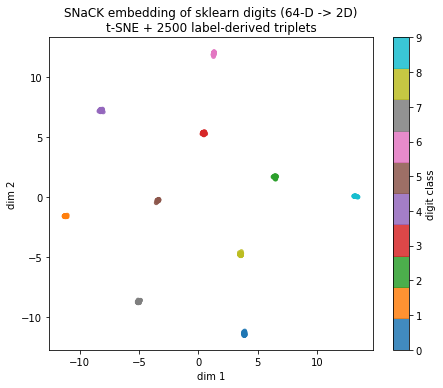

Saved snack_demo.png - digit classes form distinct groups guided by the triplets.


In [2]:
from __future__ import print_function
import numpy as np
get_ipython().run_line_magic("matplotlib", "inline")   # render figure inline in the notebook
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from snack import snack_embed

d = load_digits()
X = np.ascontiguousarray(d.data[:500], dtype=np.float64)   # must be C-contiguous float64
y = d.target[:500]
print("Input X:", X.shape, X.dtype)

# Build label-derived triplets (a,b,c): a,b same class; c different class
rng = np.random.RandomState(0)
trips = []
for _ in range(2500):
    a = rng.randint(len(y))
    same = np.where(y == y[a])[0]
    diff = np.where(y != y[a])[0]
    b = same[rng.randint(len(same))]
    c = diff[rng.randint(len(diff))]
    trips.append((a, b, c))
triplets = np.ascontiguousarray(np.array(trips), dtype=np.int64)  # must be int64
print("Triplets:", triplets.shape, triplets.dtype)

Y = np.asarray(snack_embed(X, 1.0, triplets, 0.1,
                           perplexity=30.0, max_iter=200, verbose=False))
print("Output embedding Y:", Y.shape)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(Y[:, 0], Y[:, 1], c=y, cmap="tab10", s=14, alpha=0.85)
fig.colorbar(sc, ax=ax, label="digit class")
ax.set_title("SNaCK embedding of sklearn digits (64-D -> 2D)\nt-SNE + 2500 label-derived triplets")
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
fig.tight_layout()
fig.savefig("snack_demo.png", dpi=110)
plt.show()
print("Saved snack_demo.png - digit classes form distinct groups guided by the triplets.")